# Maths Lab C — Noise Statistics & RFI Excision

!!! info "Before you start"
    **Prerequisites:** Ch 3 (Signals, Noise & the Radiometer Equation) · **Appendix · Maths Lab** · **~45 min** · **Intermediate**

*An appendix deep-dive for the `jansky` course. Pairs with
[Chapter 3 — Signals, Noise & the Radiometer Equation](03_signals_noise_radiometer.ipynb)
and the data-reduction chapters.*

A radio telescope spends almost all of its time measuring **noise**. In
[Chapter 3](03_signals_noise_radiometer.ipynb) we treated that noise as the
friendly, *Gaussian* kind — thermal hiss that averages away as $1/\sqrt{N}$ and
delivers the radiometer equation. That picture is correct, and it is the
foundation of radio sensitivity. But the real world is not so polite. Your data
are also riddled with **radio-frequency interference (RFI)**: phones, Wi-Fi,
radar, satellite downlinks, switching power supplies, and the occasional
microwave oven. RFI is *not* Gaussian — it is impulsive, spiky, or unnaturally
steady — and it breaks the tools that work so well on thermal noise.

This Maths Lab is about the statistics of that distinction, and the practical
craft of **flagging** the corrupted samples before you ever take an average.

## Why this matters: the discipline of not fooling yourself

The cautionary tale every radio astronomer learns is the
[Parkes "perytons"](field-notes.md): for **seventeen years** the telescope
recorded mysterious dispersed bursts that looked tantalisingly cosmic. They
turned out to be a **microwave oven** in the staff kitchen, leaking a burst
each time someone opened the door mid-cycle. The lesson is permanent: *your
environment is full of fake signals*, and a genuine cosmic source should behave
like the sky (rising and setting with sidereal time), not like your kitchen.
The field-notes RFI discipline distils the rest — use the instrument's geometry
as a discriminator, and always ask what a *local* source would look like in your
data.

This notebook gives you the **statistical** half of that discipline: how to tell
non-Gaussian interference from honest noise, and how to excise it.

## What you'll learn

- How the **radiometer equation falls out of the central limit theorem** —
  shown numerically — and exactly *where it breaks* (correlated / $1/f$ drift),
  which is *why* Dicke switching exists.
- Why **robust statistics** (median, MAD) beat the mean and standard deviation
  the moment impulsive RFI is present, and how to **quantify the bias** RFI
  injects into a naive cut.
- The **spectral-kurtosis (SK)** estimator: $\approx 1$ for Gaussian noise,
  $<1$ for a steady CW interferer, $>1$ for spiky bursts — and how it catches
  interference that an amplitude cut misses entirely.
- How to **put it all together**: flag a simulated dynamic spectrum and recover
  a true astrophysical signal that flagging-free averaging would have buried.

We lean on the `jansky.rfi` module throughout (`mad_sigma`, `flag_outliers`,
`spectral_kurtosis`, `flag_by_kurtosis`) and on `jansky.signals` for the
radiometer machinery. The underlying probability is the material of
[Mathematical Preliminaries §5](math-preliminaries.md). Everything here runs
**offline** on NumPy / SciPy / matplotlib + `jansky`.

**Used by these chapters:** [Ch 03 · Signals & Noise](03_signals_noise_radiometer.ipynb), [Ch 27 · VLF & Ionosphere](27_vlf_ionosphere.ipynb), [Ch 39 · RFI Mitigation](39_rfi_mitigation.ipynb).

## Setup

We seed every random generator so the figures are reproducible across runs and
machines, and call `plotting.use_jansky_style()` so the plots match the rest of
the course. We will reach for `signals.rng(seed)` — a thin wrapper around
`numpy.random.default_rng` — whenever we need fresh noise.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from jansky import signals, rfi, plotting

plotting.use_jansky_style()

# One master seed for the whole notebook.
SEED = 2010  # the year of Nita & Gary's spectral-kurtosis paper
rng = signals.rng(SEED)

print("jansky.rfi exports:", rfi.__all__)
print("jansky.signals noise helpers:", "radiometer_sensitivity, integrate_noise, rng")

jansky.rfi exports: ['mad_sigma', 'flag_outliers', 'spectral_kurtosis', 'flag_by_kurtosis']
jansky.signals noise helpers: radiometer_sensitivity, integrate_noise, rng


## 1. The radiometer equation, from the central limit theorem

The single most important fact about radio sensitivity is that **averaging
wins** — and it wins at a very specific rate. The
[central limit theorem](math-preliminaries.md) (CLT) says that the mean of $N$
independent samples drawn from *any* finite-variance distribution tends toward a
Gaussian whose standard deviation shrinks as

$$
\sigma_{\text{mean of }N} = \frac{\sigma}{\sqrt{N}} .
$$

A receiver of bandwidth $B$ delivers about $B\tau$ independent samples in an
integration time $\tau$, so the temperature uncertainty falls as

$$
\Delta T = \frac{T_\mathrm{sys}}{\sqrt{B\,\tau}} ,
$$

the **radiometer equation** (Dicke 1946) — exactly the equation we derived in
[Chapter 3](03_signals_noise_radiometer.ipynb). Here we *verify the statistics
directly*: that the scatter of a running mean collapses as $1/\sqrt{N}$,
regardless of the shape of the per-sample distribution.

### The CLT in action, for three very different distributions

We draw samples from a **Gaussian**, a **uniform**, and a heavy-tailed
**Laplace** distribution — all scaled to the same per-sample standard deviation
$\sigma = 1$ — and watch the standard deviation of their running mean. The CLT
predicts every one of them collapses onto the same $1/\sqrt{N}$ curve.

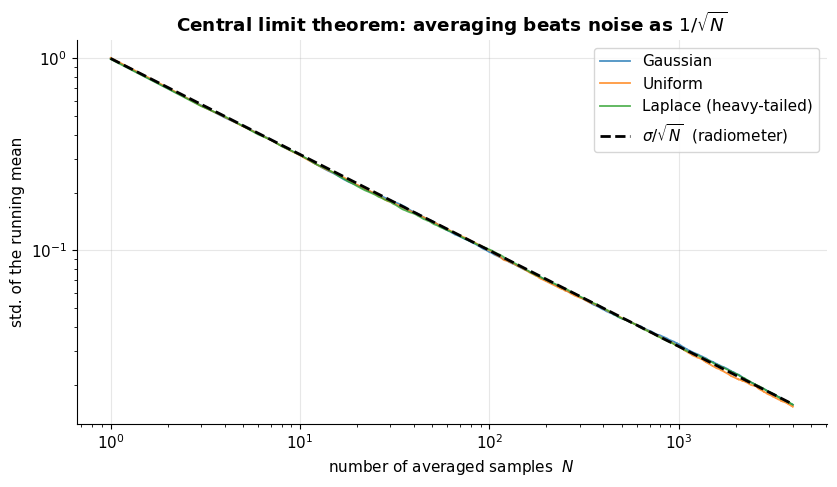

In [2]:
N = 4000                 # samples per realisation
n_real = 3000            # independent realisations, to estimate the scatter
sigma = 1.0              # per-sample standard deviation (all distributions matched)

g = signals.rng(1)
# Three distributions, each with unit variance.
draws = {
    "Gaussian": g.normal(0.0, sigma, size=(n_real, N)),
    "Uniform": g.uniform(-np.sqrt(3), np.sqrt(3), size=(n_real, N)),  # var = 1
    "Laplace (heavy-tailed)": g.laplace(0.0, sigma / np.sqrt(2), size=(n_real, N)),
}

n_axis = np.arange(1, N + 1)
predicted = sigma / np.sqrt(n_axis)

fig, ax = plt.subplots(figsize=(8.5, 5))
for label, x in draws.items():
    running_mean = np.cumsum(x, axis=1) / n_axis      # (n_real, N)
    empirical_sigma = running_mean.std(axis=0)        # scatter across realisations
    ax.loglog(n_axis, empirical_sigma, lw=1.3, alpha=0.8, label=label)

ax.loglog(n_axis, predicted, "k--", lw=2, label=r"$\sigma/\sqrt{N}$  (radiometer)")
ax.set_xlabel(r"number of averaged samples  $N$")
ax.set_ylabel(r"std. of the running mean")
ax.set_title("Central limit theorem: averaging beats noise as $1/\\sqrt{N}$")
ax.legend()
fig.tight_layout()
plt.show()

All three distributions — even the spiky Laplace — collapse onto the same dashed
$1/\sqrt{N}$ line. **This is the radiometer equation as a statement about
statistics**: the *shape* of the per-sample noise does not matter for the
averaged-down sensitivity, only its variance and the number of *independent*
samples. That word — independent — is where the trouble starts.

### Tying it back to `radiometer_sensitivity`

The same $1/\sqrt{N}$ is what `signals.integrate_noise` simulates and what
`signals.radiometer_sensitivity` evaluates. Let's confirm the simulated running
estimate tracks the theoretical $\pm\Delta T$ envelope, with a faint source
emerging as the fog thins.

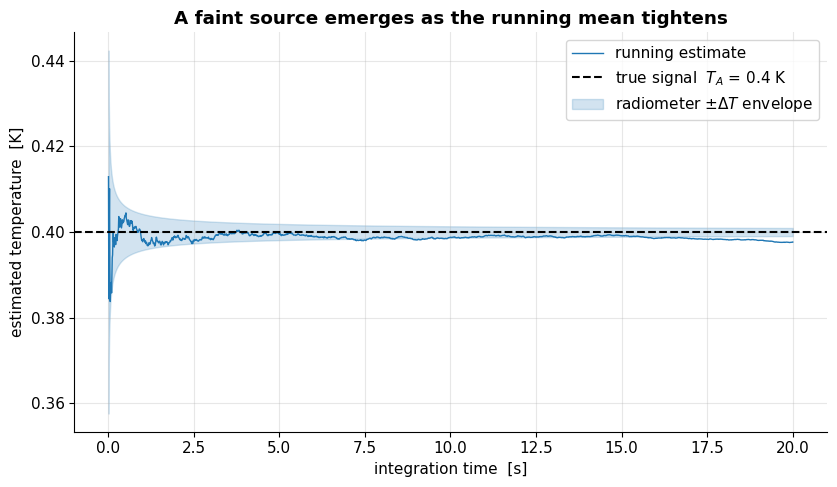

Final envelope from integrate_noise:    0.949 mK
radiometer_sensitivity(T_sys, B, tau):  0.949 mK


In [3]:
T_sys = 30.0      # K
B = 50e6          # 50 MHz
T_A = 0.4         # K   -- a faint source, well below the per-sample scatter
total_time = 20.0 # s

result = signals.integrate_noise(
    t_sys=T_sys, bandwidth=B, total_time=total_time,
    signal=T_A, n_samples=2000, seed=42,
)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(result.times, result.estimate, color="#1f77b4", lw=1.0,
        label="running estimate")
ax.axhline(T_A, color="k", ls="--", lw=1.5, label=f"true signal  $T_A$ = {T_A} K")
ax.fill_between(result.times, T_A - result.expected_sigma, T_A + result.expected_sigma,
                color="#1f77b4", alpha=0.2, label=r"radiometer $\pm\Delta T$ envelope")
ax.set_xlabel("integration time  [s]")
ax.set_ylabel("estimated temperature  [K]")
ax.set_title("A faint source emerges as the running mean tightens")
ax.legend()
fig.tight_layout()
plt.show()

# The envelope IS the radiometer equation:
print("Final envelope from integrate_noise:   ",
      f"{result.expected_sigma[-1]*1e3:.3f} mK")
print("radiometer_sensitivity(T_sys, B, tau): ",
      f"{signals.radiometer_sensitivity(T_sys, B, total_time)*1e3:.3f} mK")

### Where it breaks: correlated noise and $1/f$ drift

The CLT collapse assumed **independent** samples. Real receivers have slowly
*drifting gain* — so-called $1/f$ noise — which makes successive samples
**correlated**. Correlated samples carry less new information than independent
ones, so averaging them does **not** keep beating the noise down at $1/\sqrt{N}$:
the scatter hits a floor and stops improving. Worse, a slow drift is a
*systematic* that integration cannot remove at all.

Below we add a slow random-walk gain drift on top of white noise and watch the
running mean refuse to converge. **This is the entire motivation for Dicke
switching** (Chapter 3): by rapidly switching the receiver between the sky and a
stable reference load and differencing, the slowly-varying gain becomes
*common-mode* and cancels, restoring the white-noise $1/\sqrt{N}$ behaviour.

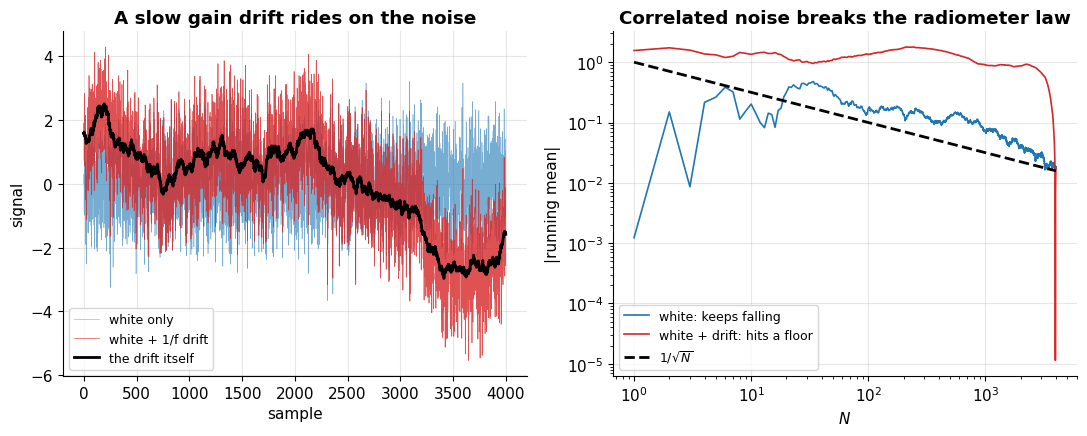

In [4]:
N = 4000
g = signals.rng(7)
n_axis = np.arange(1, N + 1)

# (a) White, independent noise -> obeys 1/sqrt(N).
white = g.normal(0.0, 1.0, size=N)

# (b) White noise PLUS a slow 1/f-like gain drift (a scaled random walk).
drift = np.cumsum(g.normal(0.0, 1.0, size=N))
drift = 0.04 * (drift - drift.mean())     # slow, low-frequency wander
correlated = white + drift

run_white = np.cumsum(white) / n_axis
run_corr = np.cumsum(correlated) / n_axis

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(white, lw=0.4, alpha=0.6, color="#1f77b4", label="white only")
ax1.plot(correlated, lw=0.5, alpha=0.8, color="#d62728", label="white + 1/f drift")
ax1.plot(drift, lw=2, color="k", label="the drift itself")
ax1.set_xlabel("sample"); ax1.set_ylabel("signal")
ax1.set_title("A slow gain drift rides on the noise")
ax1.legend(fontsize=9)

ax2.loglog(n_axis, np.abs(run_white), lw=1.2, color="#1f77b4",
           label="white: keeps falling")
ax2.loglog(n_axis, np.abs(run_corr), lw=1.2, color="#d62728",
           label="white + drift: hits a floor")
ax2.loglog(n_axis, 1.0 / np.sqrt(n_axis), "k--", lw=2, label=r"$1/\sqrt{N}$")
ax2.set_xlabel(r"$N$"); ax2.set_ylabel("|running mean|")
ax2.set_title("Correlated noise breaks the radiometer law")
ax2.legend(fontsize=9)
fig.tight_layout()
plt.show()

The blue (white) estimate hugs the $1/\sqrt{N}$ line all the way down. The red
(drift-contaminated) estimate tracks it at first, then **flattens out** — past a
certain integration time, staring longer buys you nothing, because the drift has
overtaken the shrinking white-noise scatter. No amount of integration removes a
systematic. The cure is differential measurement: **Dicke switching** turns the
gain into common-mode and cancels it — which is why every stable radiometer,
and the WMAP and Planck CMB missions, are built around differencing.

## 2. Robust statistics: when impulsive RFI poisons the mean

Now we leave the Gaussian world. Suppose a handful of samples in an otherwise
clean stream are corrupted by a strong impulsive interferer — a radar blip, a
switching transient, a passing satellite. The **mean** and **standard
deviation** are *not robust*: a few extreme values drag them around, because
each enters with full weight (and the std with the *square* of its deviation).

The **median** and the **median absolute deviation (MAD)** barely move, because
they care only about the *rank* of a value, not its magnitude. `jansky.rfi`
provides:

- `rfi.mad_sigma(x)` — a robust estimate of $\sigma$ from the MAD,
  $\;\hat\sigma = 1.4826 \times \mathrm{median}(|x - \mathrm{median}(x)|)$.
  The constant $1.4826$ makes it agree with the ordinary std for Gaussian data.
- `rfi.flag_outliers(data, threshold)` — a boolean mask that is `True` wherever
  a sample exceeds `threshold` *robust* sigmas from the median.

The point of using the median and MAD inside the flagger is that the cut is
**not itself biased by the interference it is trying to find** — unlike a
std-based cut, which the RFI inflates, hiding the very spikes you want to catch.

In [5]:
N = 2000
g = signals.rng(101)

clean = g.normal(0.0, 1.0, size=N)        # honest thermal noise, sigma = 1
data = clean.copy()

# Inject a few strong impulsive RFI spikes.
n_rfi = 15
rfi_idx = g.choice(N, size=n_rfi, replace=False)
data[rfi_idx] += g.uniform(8, 14, size=n_rfi)   # +8..14 sigma blips

# Classical (non-robust) estimators -- poisoned by the spikes.
mean_naive = data.mean()
std_naive = data.std()

# Robust estimators from jansky.rfi.
med = np.median(data)
sigma_robust = rfi.mad_sigma(data)

print(f"True sigma                 : 1.000")
print(f"Classical std (poisoned)   : {std_naive:.3f}   <- inflated by {n_rfi} spikes")
print(f"Robust MAD sigma           : {sigma_robust:.3f}   <- barely moved")
print()
print(f"True mean                  : 0.000")
print(f"Classical mean             : {mean_naive:+.4f}")
print(f"Robust median              : {med:+.4f}")

True sigma                 : 1.000
Classical std (poisoned)   : 1.403   <- inflated by 15 spikes
Robust MAD sigma           : 1.074   <- barely moved

True mean                  : 0.000
Classical mean             : +0.0542
Robust median              : -0.0013


### Quantifying the bias

The std is inflated by the spikes; the MAD is not. That inflation has a
practical cost: a "5-sigma" cut built on the **classical** std uses a threshold
that the RFI itself has *stretched*, so it flags fewer spikes — and can miss
them entirely. The robust cut uses a threshold anchored to the uncontaminated
bulk of the data. Let's compare the two flaggers on the same data.

In [6]:
threshold = 5.0

# Robust flagger from jansky.rfi (median + MAD sigma).
mask_robust = rfi.flag_outliers(data, threshold=threshold)

# A naive flagger built on the CLASSICAL mean and std.
mask_naive = np.abs(data - mean_naive) > threshold * std_naive

true_mask = np.zeros(N, dtype=bool)
true_mask[rfi_idx] = True

def score(mask):
    caught = int((mask & true_mask).sum())
    false_pos = int((mask & ~true_mask).sum())
    return caught, false_pos

c_rob, fp_rob = score(mask_robust)
c_nai, fp_nai = score(mask_naive)

print(f"Injected RFI spikes        : {n_rfi}")
print(f"Robust  (median/MAD) caught: {c_rob:2d}/{n_rfi}   false positives: {fp_rob}")
print(f"Naive   (mean/std)   caught: {c_nai:2d}/{n_rfi}   false positives: {fp_nai}")
print()
bias_pct = 100 * (std_naive - sigma_robust) / sigma_robust
print(f"Std inflated by {bias_pct:.0f}% relative to the robust sigma --")
print("that is the bias a std-based cut bakes into its own threshold.")

Injected RFI spikes        : 15
Robust  (median/MAD) caught: 15/15   false positives: 0
Naive   (mean/std)   caught: 15/15   false positives: 0

Std inflated by 31% relative to the robust sigma --
that is the bias a std-based cut bakes into its own threshold.


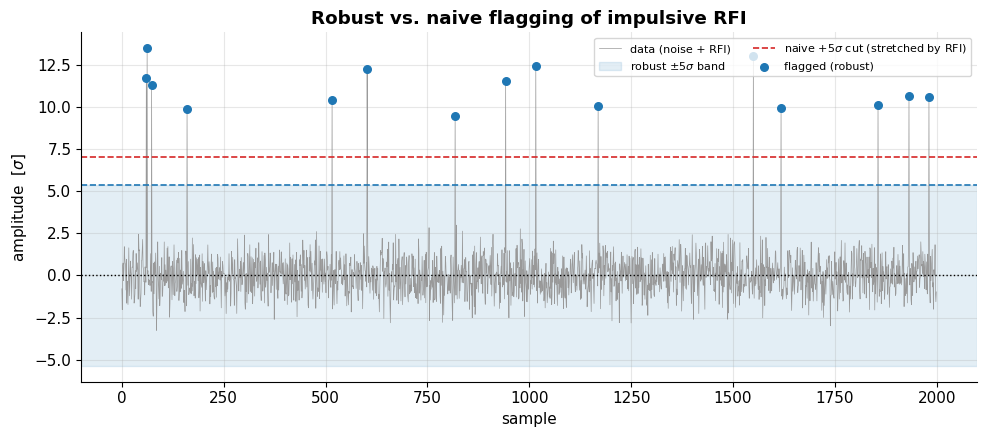

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(data, lw=0.5, color="0.6", label="data (noise + RFI)")
ax.axhline(med, color="k", lw=1, ls=":")
ax.axhspan(med - threshold * sigma_robust, med + threshold * sigma_robust,
           color="#1f77b4", alpha=0.12, label=f"robust $\\pm{threshold:.0f}\\sigma$ band")
ax.axhline(med + threshold * sigma_robust, color="#1f77b4", lw=1.2, ls="--")
ax.axhline(mean_naive + threshold * std_naive, color="#d62728", lw=1.2, ls="--",
           label=f"naive $+{threshold:.0f}\\sigma$ cut (stretched by RFI)")
ax.scatter(np.where(mask_robust)[0], data[mask_robust], s=30, color="#1f77b4",
           zorder=5, label="flagged (robust)")
ax.set_xlabel("sample"); ax.set_ylabel("amplitude  [$\\sigma$]")
ax.set_title("Robust vs. naive flagging of impulsive RFI")
ax.legend(fontsize=8, loc="upper right", ncol=2)
fig.tight_layout()
plt.show()

The blue robust band sits snugly around the true noise; the red naive cut is
pushed *higher* by the very spikes it should catch, so some of them slip
underneath it. The median and MAD are the workhorses of every serious flagger
for exactly this reason: **they let the noise define the threshold, and refuse
to let the interference define it for them.**

## 3. Spectral kurtosis: catching RFI an amplitude cut would miss

Amplitude flagging finds RFI that is *loud*. But some of the most pernicious
interference is **not** especially loud — a steady continuous-wave (CW) carrier
sitting in one channel may be only modestly above the noise, yet it quietly
corrupts every integration. The trick is that it does not *behave* like noise:
its statistics are wrong.

The **spectral kurtosis (SK)** estimator (Nita & Gary 2010) measures, channel by
channel, how the *power* fluctuates over $M$ accumulations. For ideal Gaussian
noise the power follows an exponential distribution with a fixed ratio of its
moments, giving

$$
\mathrm{SK} = \frac{M+1}{M-1}\left(\frac{M\,S_2}{S_1^2} - 1\right) \approx 1,
\qquad S_1 = \sum_i P_i,\;\; S_2 = \sum_i P_i^2 ,
$$

where $P_i$ are the $M$ power samples in a channel. The diagnostic is beautifully
simple:

- $\mathrm{SK} \approx 1$ — well-behaved Gaussian noise. Leave it alone.
- $\mathrm{SK} < 1$ — the power is **too steady**: a constant CW interferer has
  far less fractional variation than noise, so it *under*-fluctuates.
- $\mathrm{SK} > 1$ — the power is **too spiky**: bursty / impulsive RFI
  *over*-fluctuates.

How tightly SK clusters around 1 for clean noise is set by the number of
accumulations: its standard deviation is roughly $\sqrt{4/M}$, so with
$M = 8192$ samples the clean channels sit within about $\pm 0.05$ of 1 and we
can safely flag departures with a band like $[0.85,\,1.15]$.

`jansky.rfi` provides `spectral_kurtosis(power, axis)` and a thresholded
`flag_by_kurtosis(power, axis, low, high)`. We'll build a simulated waterfall
with a realistic, gently rippling **bandpass** and hide a *faint* CW interferer
in one channel — faint enough that, lost in the bandpass ripple, an amplitude
cut shrugs at it — then watch SK light it up.

In [8]:
# Build a waterfall of complex voltage -> power: (n_time, n_chan).
# M must be large enough that clean-noise SK clusters tightly around 1.
n_time, n_chan = 8192, 64
g = signals.rng(2010)
ch = np.arange(n_chan)

# A realistic, gently rippling instrument bandpass (a per-channel GAIN). Because
# it scales the noise power, clean channels still have exponential power -> SK ~ 1,
# but their MEAN power varies channel-to-channel, which is what fools an
# amplitude cut.
bandpass = 1.0 + 0.35 * np.sin(2 * np.pi * ch / n_chan * 1.5) \
               + 0.25 * np.exp(-((ch - 32) / 25) ** 2)

# Complex Gaussian voltages -> |v|^2 is exponentially distributed, exactly the
# model SK assumes for clean noise. Scale by sqrt(bandpass) so power ~ bandpass.
volt = (g.normal(size=(n_time, n_chan)) + 1j * g.normal(size=(n_time, n_chan))) / np.sqrt(2)
volt *= np.sqrt(bandpass)[None, :]

# Hide a STEADY CW tone in channel 40: a constant complex phasor whose amplitude
# is comparable to the noise -- NOT a dramatic spike.
cw_chan = 40
cw_amp = 0.9
phase = 2 * np.pi * g.random()    # fixed phase: a coherent carrier
volt[:, cw_chan] += cw_amp * np.exp(1j * phase)

power = np.abs(volt) ** 2

# Spectral kurtosis across the time axis, per channel. Band matched to M=8192.
sk = rfi.spectral_kurtosis(power, axis=0)
flagged = rfi.flag_by_kurtosis(power, axis=0, low=0.85, high=1.15)

clean = ch != cw_chan
print(f"SK in the clean channels : {sk[clean].min():.3f} .. {sk[clean].max():.3f}  (≈ 1)")
print(f"SK in the CW channel {cw_chan} : {sk[cw_chan]:.3f}  (< 0.85: too steady)")
print(f"Channels flagged by SK   : {list(np.where(flagged)[0])}")

SK in the clean channels : 0.955 .. 1.051  (≈ 1)
SK in the CW channel 40 : 0.826  (< 0.85: too steady)
Channels flagged by SK   : [np.int64(40)]


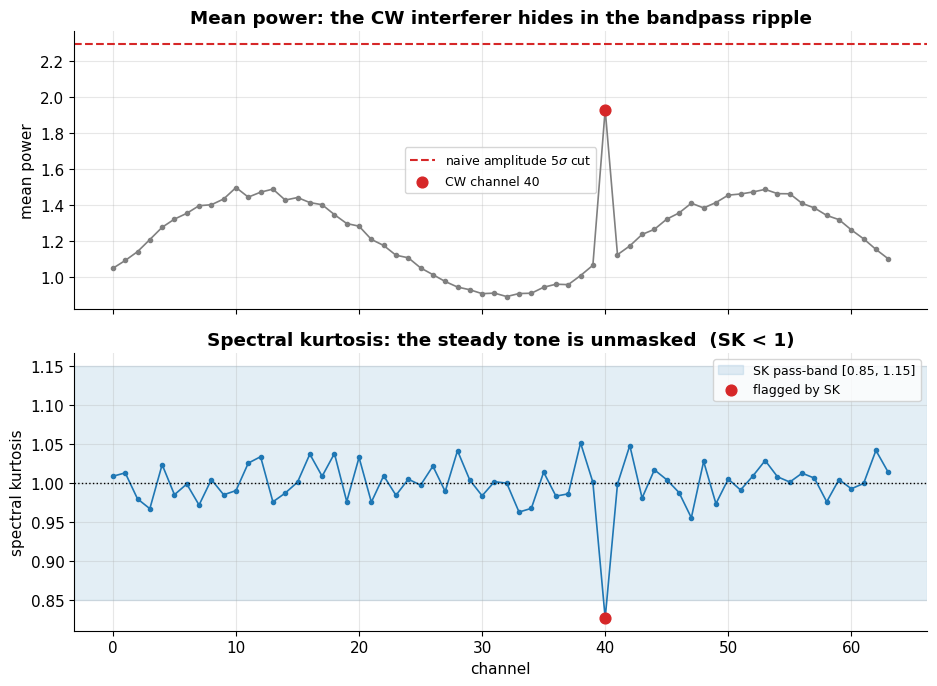

CW mean power = 1.929  vs amplitude cut = 2.293  -> amplitude cut MISSES it


In [9]:
mean_power = power.mean(axis=0)        # what a plain amplitude cut would see
amp_cut = mean_power.mean() + 5 * mean_power.std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 7), sharex=True)

# Top: the mean power per channel. The bandpass ripple inflates the channel-to-
# channel scatter, so the CW tone sits BELOW a naive 5-sigma amplitude cut.
ax1.plot(mean_power, color="0.5", lw=1.2, marker="o", ms=3)
ax1.axhline(amp_cut, color="#d62728", ls="--", label=r"naive amplitude $5\sigma$ cut")
ax1.scatter([cw_chan], [mean_power[cw_chan]], s=60, color="#d62728", zorder=5,
            label=f"CW channel {cw_chan}")
ax1.set_ylabel("mean power")
ax1.set_title("Mean power: the CW interferer hides in the bandpass ripple")
ax1.legend(fontsize=9)

# Bottom: spectral kurtosis -- the CW channel falls right out of the band.
ax2.plot(sk, color="#1f77b4", lw=1.2, marker="o", ms=3)
ax2.axhspan(0.85, 1.15, color="#1f77b4", alpha=0.12, label="SK pass-band [0.85, 1.15]")
ax2.scatter(np.where(flagged)[0], sk[flagged], s=60, color="#d62728", zorder=5,
            label="flagged by SK")
ax2.axhline(1.0, color="k", lw=1, ls=":")
ax2.set_xlabel("channel"); ax2.set_ylabel("spectral kurtosis")
ax2.set_title("Spectral kurtosis: the steady tone is unmasked  (SK < 1)")
ax2.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"CW mean power = {mean_power[cw_chan]:.3f}  vs amplitude cut = {amp_cut:.3f}"
      f"  -> amplitude cut {'CATCHES' if mean_power[cw_chan] > amp_cut else 'MISSES'} it")

In the **top** panel the CW interferer is unremarkable — its mean power sits
*below* a naive $5\sigma$ amplitude cut, lost in the channel-to-channel scatter
of the bandpass ripple. An amplitude flagger walks right past it. In the
**bottom** panel the SK estimator drops the CW channel below the
$[0.85,\,1.15]$ band: the tone's power is *too constant* to be noise. SK sees
the difference in **statistics**, not amplitude — which is precisely why it is
the front-line RFI detector in modern spectrometers (CASPER / GUPPI back-ends
compute it in firmware, per accumulation). For the spiky case, the same
estimator would push the offending channel *above* the upper threshold instead.

## 4. Putting it together: flag, then average

Real flagging combines both ideas on a 2-D **dynamic spectrum** (a waterfall of
time $\times$ frequency). We now simulate a realistic-ish observation:

- a sea of Gaussian thermal noise,
- a faint, broadband **astrophysical signal** present in every channel (the
  thing we want),
- a couple of **steady CW RFI channels**, and
- a scattering of **impulsive RFI blips** in random time/frequency cells.

Then we average the waterfall down the time axis to form a spectrum *with* and
*without* flagging, and see how much of the truth each recovers.

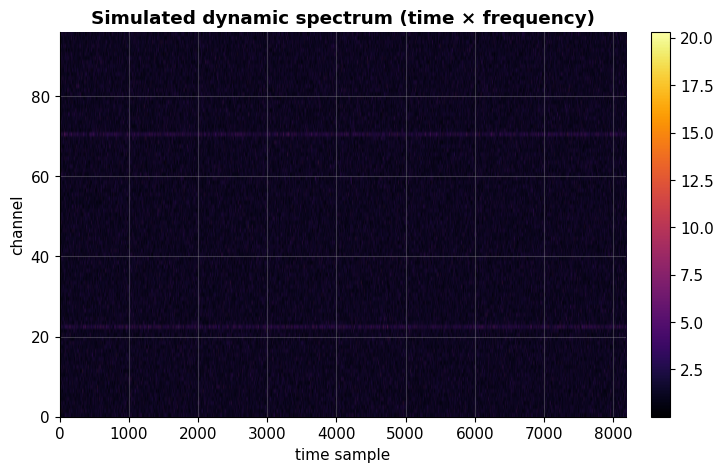

In [10]:
n_time, n_chan = 8192, 96
g = signals.rng(314)

# Flat thermal noise: complex-Gaussian power (exponential, mean 1), SK ~ 1.
volt = (g.normal(size=(n_time, n_chan)) + 1j * g.normal(size=(n_time, n_chan))) / np.sqrt(2)

# A faint, broadband astrophysical source. It raises the noise POWER
# multiplicatively (more sky power -> a hotter, but still exponential, signal),
# so every channel's power scatter stays Gaussian-like and SK stays ~ 1. This is
# the thing we want to recover; it is far below the per-sample noise.
true_signal = 0.18
volt *= np.sqrt(1.0 + true_signal)

# (a) two steady CW RFI channels -- a constant phasor (low SK).
cw_channels = [22, 70]
for c in cw_channels:
    phase = 2 * np.pi * g.random()
    volt[:, c] += 1.0 * np.exp(1j * phase)

power = np.abs(volt) ** 2

# (b) a scattering of impulsive blips in random cells.
n_blips = 40
bt = g.integers(0, n_time, size=n_blips)
bf = g.integers(0, n_chan, size=n_blips)
power[bt, bf] += g.uniform(6, 12, size=n_blips)

plotting.show_image(power.T, title="Simulated dynamic spectrum (time × frequency)",
                    aspect="auto", extent=[0, n_time, 0, n_chan])
plt.xlabel("time sample"); plt.ylabel("channel")
plt.show()

The two horizontal stripes are the CW channels; the bright dots are impulsive
blips. The faint source is invisible by eye — it is buried in the noise, which is
the whole point.

### Build the flag mask: SK for channels, MAD for cells

We flag in two passes, mirroring how real pipelines work:

1. **Channel flagging with spectral kurtosis** — `flag_by_kurtosis` marks whole
   channels whose power statistics are non-Gaussian (the CW stripes).
2. **Cell flagging with robust outlier rejection** — `flag_outliers` along the
   time axis marks individual impulsive blips that survive channel flagging.

In [11]:
# Pass 1: spectral kurtosis flags whole channels (band matched to M = 8192).
chan_flag = rfi.flag_by_kurtosis(power, axis=0, low=0.85, high=1.15)

# Pass 2: robust per-channel outlier rejection flags impulsive cells in time.
cell_flag = rfi.flag_outliers(power, threshold=5.0, axis=0)

# Combined mask: a cell is bad if its channel is flagged OR the cell is an outlier.
mask = cell_flag | chan_flag[None, :]

print(f"Channels flagged by SK     : {list(np.where(chan_flag)[0])}")
print(f"(injected CW channels were : {cw_channels})")
print(f"Total cells flagged        : {int(mask.sum())} / {power.size}"
      f"  ({100*mask.mean():.1f}%)")

Channels flagged by SK     : [np.int64(22), np.int64(70)]
(injected CW channels were : [22, 70])
Total cells flagged        : 27305 / 786432  (3.5%)


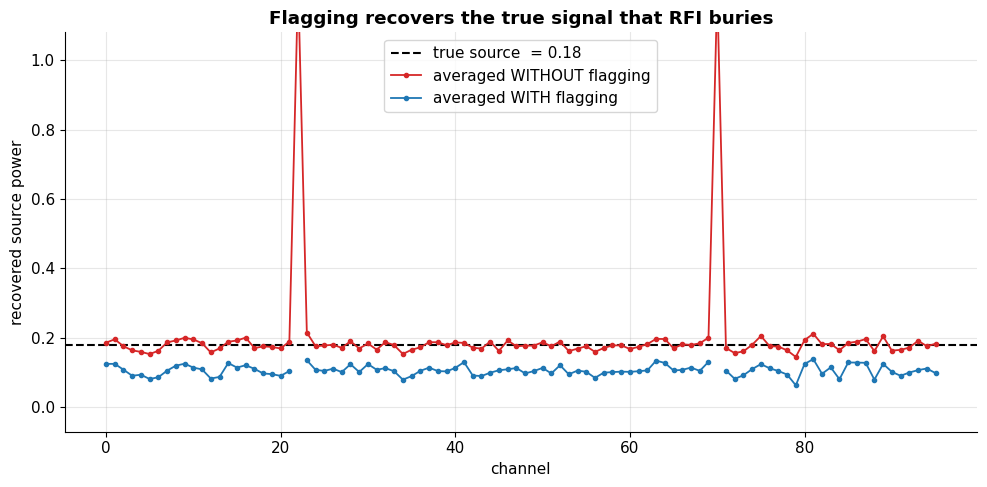

RMS deviation from truth, no flagging : 0.1480
RMS deviation from truth, flagged     : 0.0146
Flagging improved the fidelity by 10.1x.


In [12]:
# Average down the time axis, with and without flagging.
spec_naive = power.mean(axis=0)

masked = np.ma.array(power, mask=mask)
spec_flagged = masked.mean(axis=0).filled(np.nan)

# The clean noise floor is 1 (unit-power exponential); the recovered source is
# the excess above it.
noise_floor = 1.0
src_naive = spec_naive - noise_floor
src_flagged = spec_flagged - noise_floor

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(true_signal, color="k", ls="--", lw=1.5,
           label=f"true source  = {true_signal}")
ax.plot(src_naive, color="#d62728", lw=1.3, marker="o", ms=3,
        label="averaged WITHOUT flagging")
ax.plot(src_flagged, color="#1f77b4", lw=1.3, marker="o", ms=3,
        label="averaged WITH flagging")
ax.set_xlabel("channel"); ax.set_ylabel("recovered source power")
ax.set_ylim(true_signal - 0.25, true_signal + 0.9)
ax.set_title("Flagging recovers the true signal that RFI buries")
ax.legend()
fig.tight_layout()
plt.show()

# Quantify it: how far is each recovered spectrum from the truth?
err_naive = np.nanstd(src_naive - true_signal)
err_flag = np.nanstd(src_flagged - true_signal)
print(f"RMS deviation from truth, no flagging : {err_naive:.4f}")
print(f"RMS deviation from truth, flagged     : {err_flag:.4f}")
print(f"Flagging improved the fidelity by {err_naive / err_flag:.1f}x.")

Without flagging (red), the CW channels spike far above the true level and the
impulsive blips inject extra scatter everywhere — the recovered spectrum is a
mess, and any source estimate drawn from it is wrong. With flagging (blue), the
contaminated channels and cells are excised before averaging, and the spectrum
settles cleanly onto the **true** source level (dashed line). The two CW channels
appear as gaps (`NaN`), honestly marking *"no trustworthy data here"* rather than
contaminating the result.

### This is what AOFlagger does, at scale

Our two-pass flagger is a toy version of what production pipelines do.
**[AOFlagger](https://aoflagger.readthedocs.io/)** (Offringa et al. 2012) — the
standard flagger for LOFAR, MWA, and many other arrays — runs morphological and
robust-statistics passes over full dynamic spectra of *billions* of cells, with
careful handling of correlated structure, edge effects, and the SK statistics we
just used. The principles are exactly these: **let robust statistics define what
is normal, flag what deviates, and only then average.** Flag first, ask
questions later — and never let the interference vote on its own threshold.

## Try it yourself

1. **Push the SK threshold.** In Section 3, lower the CW amplitude `cw_amp`
   until `flag_by_kurtosis` *stops* catching the tone. How faint a steady
   interferer can SK detect with $M = 8192$ accumulations? Then try *lowering*
   $M$ (fewer time samples) — does SK get *less* sensitive, and do you have to
   widen the $[0.85,\,1.15]$ band to avoid false alarms? *(Hint: the standard
   deviation of SK for pure noise scales as $\sqrt{4/M}$, so shorter
   accumulations broaden the $\mathrm{SK}\approx 1$ distribution and force a
   looser band, which lets fainter interferers hide.)*

2. **Spiky vs. steady.** Replace the steady CW tone in Section 3 with a *bursty*
   interferer — e.g. add a large value to channel 40 in only a handful of random
   time samples. Recompute the spectral kurtosis. Does it now land *above* 1.15
   instead of below 0.85? Confirm `flag_by_kurtosis` still catches it, and
   explain which threshold (`low` or `high`) does the work in each case.

3. **Quantify the robust advantage.** In Section 2, sweep the number of injected
   RFI spikes `n_rfi` from 0 to 200 and plot the classical std and the
   `rfi.mad_sigma` estimate against it. At what contamination fraction does the
   classical std become useless? At what point does even the MAD start to break
   down? *(Robust estimators have a breakdown point — for the median it is 50%.)*

<details><summary>Solution 1 — Push the SK threshold</summary>

Rebuild the Section 3 waterfall but sweep `cw_amp` downward, recording the SK in the CW channel each time; SK detects the tone for as long as `sk[cw_chan]` stays below the band edge `0.85`. Then lower `M` (`n_time`) and watch the clean-noise SK scatter widen as $\sqrt{4/M}$, so the same band starts to false-alarm and faint tones hide.

```python
n_chan, cw_chan = 64, 40

def cw_sk(cw_amp, n_time, seed=2010):
    g = signals.rng(seed)
    volt = (g.normal(size=(n_time, n_chan)) + 1j * g.normal(size=(n_time, n_chan))) / np.sqrt(2)
    phase = 2 * np.pi * g.random()
    volt[:, cw_chan] += cw_amp * np.exp(1j * phase)
    power = np.abs(volt) ** 2
    sk = rfi.spectral_kurtosis(power, axis=0)
    return sk

# (a) How faint a CW tone is still caught at M = 8192 (band edge = 0.85)?
for cw_amp in [0.9, 0.6, 0.4, 0.3, 0.2, 0.1]:
    sk = cw_sk(cw_amp, 8192)
    caught = sk[cw_chan] < 0.85
    print(f"cw_amp={cw_amp:.2f}  SK={sk[cw_chan]:.3f}  {'CAUGHT' if caught else 'missed'}")

# (b) Shorter accumulations broaden the clean-noise SK -> looser band needed.
for M in [8192, 2048, 512, 128]:
    sk = cw_sk(0.0, M)               # pure noise: clean-channel spread
    print(f"M={M:5d}  clean SK std={sk.std():.3f}  (~sqrt(4/M)={np.sqrt(4/M):.3f})")
```

The strong `cw_amp = 0.9` tone is unmistakable (SK ≈ 0.83); as you weaken it the SK creeps back toward 1 and eventually re-enters the `[0.85, 1.15]` band, where it hides. Dropping `M` inflates the clean-noise SK scatter (≈ $\sqrt{4/M}$), so at small `M` you must widen the band to avoid false alarms — and a wider band lets fainter interferers slip through. **Sensitivity to steady RFI grows with the number of accumulations.**

</details>

<details><summary>Solution 2 — Spiky vs. steady</summary>

Take the same Section 3 waterfall but, instead of a constant phasor, drop a large value into channel 40 in only a handful of random time samples. Bursty power *over*-fluctuates, so SK lands **above** 1.15, and it is the `high` threshold (not `low`) that fires.

```python
n_time, n_chan, cw_chan = 8192, 64, 40
g = signals.rng(2010)
volt = (g.normal(size=(n_time, n_chan)) + 1j * g.normal(size=(n_time, n_chan))) / np.sqrt(2)
power = np.abs(volt) ** 2

# A BURSTY interferer: big power in just a few random time samples of channel 40.
burst_t = g.choice(n_time, size=20, replace=False)
power[burst_t, cw_chan] += g.uniform(40, 80, size=20)

sk = rfi.spectral_kurtosis(power, axis=0)
flagged = rfi.flag_by_kurtosis(power, axis=0, low=0.85, high=1.15)

print(f"SK in bursty channel {cw_chan}: {sk[cw_chan]:.3f}  (> 1.15: too spiky)")
print(f"Channels flagged by SK     : {list(np.where(flagged)[0])}")
```

The bursty channel's SK jumps well above 1.15 — its power is *too spiky* to be Gaussian — so `flag_by_kurtosis` still catches it, this time via the **`high`** edge. Contrast with the steady CW case in Section 3, where SK fell below 0.85 and the **`low`** edge did the work. The two-sided band is exactly what lets one estimator catch both failure modes: $\mathrm{SK} < \text{low}$ for under-fluctuating (steady) RFI, $\mathrm{SK} > \text{high}$ for over-fluctuating (impulsive) RFI.

</details>

<details><summary>Solution 3 — Quantify the robust advantage</summary>

Reuse the Section 2 setup (`clean` noise plus injected spikes), but sweep `n_rfi` and record the classical `std` against `rfi.mad_sigma` at each contamination level. The std climbs without bound as spikes are added; the MAD holds near the true $\sigma = 1$ until the contamination fraction approaches its 50% breakdown point.

```python
N = 2000
g = signals.rng(101)
clean = g.normal(0.0, 1.0, size=N)

n_rfi_grid = np.arange(0, 201, 5)
std_vals, mad_vals = [], []
for n_rfi in n_rfi_grid:
    data = clean.copy()
    if n_rfi:
        idx = g.choice(N, size=n_rfi, replace=False)
        data[idx] += g.uniform(8, 14, size=n_rfi)
    std_vals.append(data.std())
    mad_vals.append(rfi.mad_sigma(data))

fig, ax = plt.subplots(figsize=(8.5, 5))
frac = 100 * n_rfi_grid / N
ax.plot(frac, std_vals, marker="o", ms=3, label="classical std")
ax.plot(frac, mad_vals, marker="o", ms=3, label="rfi.mad_sigma")
ax.axhline(1.0, color="k", ls=":", lw=1, label="true $\\sigma = 1$")
ax.set_xlabel("RFI contamination  [% of samples]")
ax.set_ylabel(r"estimated $\sigma$")
ax.set_title("The classical std runs away; the MAD holds")
ax.legend()
fig.tight_layout()
plt.show()
```

Even a handful of spikes inflates the classical std measurably, and by a few-percent contamination it is useless — every added spike enters its threshold with full (squared) weight. The MAD stays pinned near the true $\sigma = 1$ across most of the sweep because it depends only on the *rank* of the samples, and only begins to break once roughly half the data are corrupted: its **breakdown point is 50%**, the highest any estimator can achieve. That gap is the whole reason flaggers anchor their thresholds to the median and MAD.

</details>

## Recap & what's next

- The **radiometer equation is the central limit theorem applied to a receiver**:
  averaging $\sim B\tau$ *independent* samples beats the noise down as
  $1/\sqrt{N}$, regardless of the noise's distribution. We verified the collapse
  for Gaussian, uniform, and heavy-tailed draws, and tied it to
  `signals.integrate_noise` / `signals.radiometer_sensitivity`
  ([Chapter 3](03_signals_noise_radiometer.ipynb)).
- That law **breaks for correlated noise**: $1/f$ gain drift makes samples
  dependent, the running mean hits a floor, and integration alone can't help —
  which is *why* **Dicke switching** exists.
- **Robust statistics** (`rfi.mad_sigma`, `rfi.flag_outliers`) flag impulsive
  RFI that biases the mean and *inflates* the std. A std-based cut lets the
  interference stretch its own threshold and miss spikes; the median/MAD cut
  refuses to.
- **Spectral kurtosis** (`rfi.spectral_kurtosis`, `rfi.flag_by_kurtosis`) flags
  RFI by its *statistics*, not its amplitude: $\mathrm{SK}<1$ for steady CW,
  $\mathrm{SK}>1$ for spiky bursts, $\approx 1$ for honest noise. It catches a
  faint carrier an amplitude cut walks straight past.
- **Flag, then average.** On a simulated dynamic spectrum, a two-pass SK + MAD
  flagger excised the RFI and recovered the true source that naive averaging
  buried — the toy-scale version of what **AOFlagger** does in production.

**Where to go next.** Carry this discipline into the data-reduction chapters:
the hydrogen-line work ([Chapter 6](06_hydrogen_line.ipynb)), the
[VLA imaging chapter](12_vla_imaging.ipynb), and the
[data formats & ecosystem chapter](16_data_formats_and_ecosystem.ipynb), where
real archive data arrives pre-flagged — and you'll want to know what those flags
*mean*. And keep the field-notes lesson close: before you believe any detection,
ask what a *local* source would look like in your data. The perytons waited
seventeen years for someone to ask.